NHẬP THÔNG TIN CHUYẾN GRABBIKE
Khoảng cách: 0 - 50 km
Giao thông: 0 = thoáng, 100 = kẹt nặng
Nhu cầu: 0 = ít người đặt, 100 = rất cao
Thời tiết: 0 = tốt, 100 = xấu
Đánh giá khách hàng: 1.0 - 5.0 sao
Đúng giờ: 0 = trễ, 100 = rất sớm
Nhập khoảng cách chuyến đi km: 30
Nhập mức độ giao thông 0-100: 8
Nhập mức nhu cầu 0-100: 8
Nhập mức thời tiết 0-100: 88
Nhập đánh giá khách hàng 1-5: 5
Nhập mức độ đúng giờ 0-100: 90

KẾT QUẢ ĐÁNH GIÁ
Mức giá cước fuzzy: 91.95 / 100
Giá tiền ước tính: 213,545 VNĐ
Điểm thưởng tài xế: 80 / 100
Phân loại giá: Giá rất cao
Phân loại điểm thưởng: Điểm thưởng cao


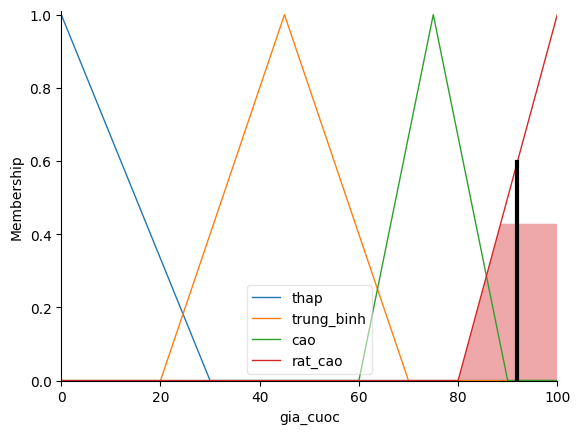

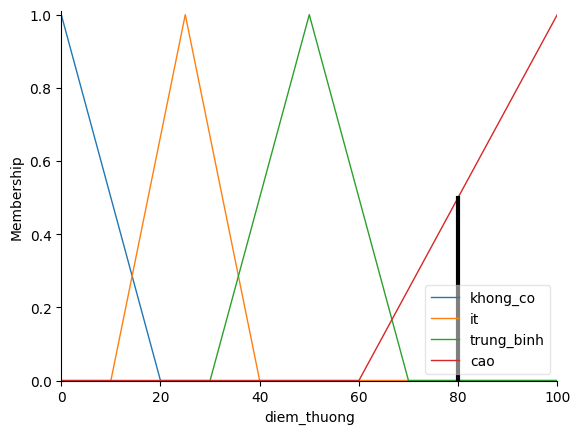

In [4]:
#Bài 2.11
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

khoang_cach = ctrl.Antecedent(np.arange(0, 51, 1), 'khoang_cach')
giao_thong = ctrl.Antecedent(np.arange(0, 101, 1), 'giao_thong')
nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau')
thoi_tiet = ctrl.Antecedent(np.arange(0, 101, 1), 'thoi_tiet')
danh_gia = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'danh_gia')
dung_gio = ctrl.Antecedent(np.arange(0, 101, 1), 'dung_gio')

gia_cuoc = ctrl.Consequent(np.arange(0, 101, 1), 'gia_cuoc')
diem_thuong = ctrl.Consequent(np.arange(0, 101, 1), 'diem_thuong')

khoang_cach['ngan'] = fuzz.trimf(khoang_cach.universe, [0, 0, 3])
khoang_cach['trung_binh'] = fuzz.trimf(khoang_cach.universe, [2, 5, 8])
khoang_cach['dai'] = fuzz.trimf(khoang_cach.universe, [6, 13, 20])
khoang_cach['rat_xa'] = fuzz.trimf(khoang_cach.universe, [15, 50, 50])

giao_thong['thap'] = fuzz.trimf(giao_thong.universe, [0, 0, 30])
giao_thong['trung_binh'] = fuzz.trimf(giao_thong.universe, [20, 45, 70])
giao_thong['cao'] = fuzz.trimf(giao_thong.universe, [60, 100, 100])

nhu_cau['thap'] = fuzz.trimf(nhu_cau.universe, [0, 0, 30])
nhu_cau['trung_binh'] = fuzz.trimf(nhu_cau.universe, [20, 45, 70])
nhu_cau['cao'] = fuzz.trimf(nhu_cau.universe, [60, 100, 100])

thoi_tiet['tot'] = fuzz.trimf(thoi_tiet.universe, [0, 0, 30])
thoi_tiet['vua_phai'] = fuzz.trimf(thoi_tiet.universe, [20, 45, 70])
thoi_tiet['xau'] = fuzz.trimf(thoi_tiet.universe, [60, 100, 100])

danh_gia['kem'] = fuzz.trimf(danh_gia.universe, [1, 1, 2.5])
danh_gia['trung_binh'] = fuzz.trimf(danh_gia.universe, [2, 3, 4])
danh_gia['tot'] = fuzz.trimf(danh_gia.universe, [3.5, 5, 5])

dung_gio['tre'] = fuzz.trimf(dung_gio.universe, [0, 0, 50])
dung_gio['dung_gio'] = fuzz.trimf(dung_gio.universe, [40, 60, 80])
dung_gio['som'] = fuzz.trimf(dung_gio.universe, [70, 100, 100])

gia_cuoc['thap'] = fuzz.trimf(gia_cuoc.universe, [0, 0, 30])
gia_cuoc['trung_binh'] = fuzz.trimf(gia_cuoc.universe, [20, 45, 70])
gia_cuoc['cao'] = fuzz.trimf(gia_cuoc.universe, [60, 75, 90])
gia_cuoc['rat_cao'] = fuzz.trimf(gia_cuoc.universe, [80, 100, 100])

diem_thuong['khong_co'] = fuzz.trimf(diem_thuong.universe, [0, 0, 20])
diem_thuong['it'] = fuzz.trimf(diem_thuong.universe, [10, 25, 40])
diem_thuong['trung_binh'] = fuzz.trimf(diem_thuong.universe, [30, 50, 70])
diem_thuong['cao'] = fuzz.trimf(diem_thuong.universe, [60, 100, 100])

rules = [ctrl.Rule(khoang_cach['ngan'] & giao_thong['thap'] & nhu_cau['thap'], gia_cuoc['thap']),
    ctrl.Rule(khoang_cach['ngan'] & giao_thong['trung_binh'] & nhu_cau['cao'], gia_cuoc['trung_binh']),
    ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['cao'] & nhu_cau['cao'], gia_cuoc['cao']),
    ctrl.Rule(khoang_cach['dai'] & giao_thong['trung_binh'] & thoi_tiet['tot'], gia_cuoc['trung_binh']),
    ctrl.Rule(khoang_cach['dai'] & giao_thong['cao'] & thoi_tiet['xau'], gia_cuoc['rat_cao']),
    ctrl.Rule(khoang_cach['rat_xa'] & giao_thong['cao'] & nhu_cau['cao'], gia_cuoc['rat_cao']),
    ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['thap'] & nhu_cau['thap'], gia_cuoc['trung_binh']),
    ctrl.Rule(khoang_cach['ngan'] & giao_thong['cao'] & nhu_cau['cao'], gia_cuoc['cao']),
    ctrl.Rule(khoang_cach['rat_xa'] & thoi_tiet['xau'], gia_cuoc['rat_cao']),
    ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['trung_binh'] & thoi_tiet['vua_phai'], gia_cuoc['trung_binh']),

    ctrl.Rule(danh_gia['tot'] & dung_gio['som'], diem_thuong['cao']),
    ctrl.Rule(danh_gia['trung_binh'] & dung_gio['dung_gio'], diem_thuong['trung_binh']),
    ctrl.Rule(danh_gia['kem'] & dung_gio['tre'], diem_thuong['khong_co']),
    ctrl.Rule(khoang_cach['dai'] & giao_thong['cao'] & dung_gio['som'], diem_thuong['cao']),
    ctrl.Rule(khoang_cach['trung_binh'] & giao_thong['trung_binh'] & danh_gia['tot'], diem_thuong['trung_binh']),
    ctrl.Rule(danh_gia['kem'] & dung_gio['tre'], diem_thuong['khong_co']),
    ctrl.Rule(khoang_cach['rat_xa'] & thoi_tiet['xau'] & danh_gia['tot'], diem_thuong['cao']),
    ctrl.Rule(khoang_cach['ngan'] & danh_gia['trung_binh'] & dung_gio['dung_gio'], diem_thuong['it']),
    ctrl.Rule(khoang_cach['dai'] & giao_thong['cao'] & dung_gio['tre'], diem_thuong['it']),
    ctrl.Rule(khoang_cach['trung_binh'] & thoi_tiet['vua_phai'] & danh_gia['tot'], diem_thuong['trung_binh'])]

he_thong = ctrl.ControlSystem(rules)
mo_phong = ctrl.ControlSystemSimulation(he_thong)

print("NHẬP THÔNG TIN CHUYẾN GRABBIKE")
print("Khoảng cách: 0 - 50 km")
print("Giao thông: 0 = thoáng, 100 = kẹt nặng")
print("Nhu cầu: 0 = ít người đặt, 100 = rất cao")
print("Thời tiết: 0 = tốt, 100 = xấu")
print("Đánh giá khách hàng: 1.0 - 5.0 sao")
print("Đúng giờ: 0 = trễ, 100 = rất sớm")

kc = float(input("Nhập khoảng cách chuyến đi km: "))
gt = float(input("Nhập mức độ giao thông 0-100: "))
nc = float(input("Nhập mức nhu cầu 0-100: "))
tt = float(input("Nhập mức thời tiết 0-100: "))
dg = float(input("Nhập đánh giá khách hàng 1-5: "))
gio = float(input("Nhập mức độ đúng giờ 0-100: "))

mo_phong.input['khoang_cach'] = kc
mo_phong.input['giao_thong'] = gt
mo_phong.input['nhu_cau'] = nc
mo_phong.input['thoi_tiet'] = tt
mo_phong.input['danh_gia'] = dg
mo_phong.input['dung_gio'] = gio

mo_phong.compute()

ket_qua_gia = mo_phong.output['gia_cuoc']
ket_qua_thuong = mo_phong.output['diem_thuong']

gia_tien_uoc_tinh = 12000 + kc * 3500 * (1 + ket_qua_gia / 100)
diem_thuong_tai_xe = round(ket_qua_thuong)

print("\nKẾT QUẢ ĐÁNH GIÁ")
print("Mức giá cước fuzzy:", round(ket_qua_gia, 2), "/ 100")
print("Giá tiền ước tính:", format(round(gia_tien_uoc_tinh), ","), "VNĐ")
print("Điểm thưởng tài xế:", diem_thuong_tai_xe, "/ 100")

if ket_qua_gia < 30:
    muc_gia = "Giá thấp"
elif ket_qua_gia < 60:
    muc_gia = "Giá trung bình"
elif ket_qua_gia < 80:
    muc_gia = "Giá cao"
else:
    muc_gia = "Giá rất cao"

if ket_qua_thuong < 20:
    muc_thuong = "Không có điểm thưởng"
elif ket_qua_thuong < 40:
    muc_thuong = "Điểm thưởng ít"
elif ket_qua_thuong < 70:
    muc_thuong = "Điểm thưởng trung bình"
else:
    muc_thuong = "Điểm thưởng cao"

print("Phân loại giá:", muc_gia)
print("Phân loại điểm thưởng:", muc_thuong)

gia_cuoc.view(sim=mo_phong)
plt.show()

diem_thuong.view(sim=mo_phong)
plt.show()

In [6]:
#Bài 2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

xep_hang = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'xep_hang')
khoi_luong = ctrl.Antecedent(np.arange(0, 101, 1), 'khoi_luong')
loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'loi_nhuan')
su_kien = ctrl.Antecedent(np.arange(0, 101, 1), 'su_kien')
doi_thu = ctrl.Antecedent(np.arange(0, 101, 1), 'doi_thu')


chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')


xep_hang['thap'] = fuzz.trimf(xep_hang.universe, [0, 0, 2.5])
xep_hang['trung_binh'] = fuzz.trimf(xep_hang.universe, [2, 3.5, 4.5])
xep_hang['cao'] = fuzz.trimf(xep_hang.universe, [4, 5, 5])

khoi_luong['thap'] = fuzz.trimf(khoi_luong.universe, [0, 0, 30])
khoi_luong['trung_binh'] = fuzz.trimf(khoi_luong.universe, [20, 50, 80])
khoi_luong['cao'] = fuzz.trimf(khoi_luong.universe, [60, 100, 100])

loi_nhuan['thap'] = fuzz.trimf(loi_nhuan.universe, [0, 0, 30])
loi_nhuan['trung_binh'] = fuzz.trimf(loi_nhuan.universe, [20, 50, 80])
loi_nhuan['cao'] = fuzz.trimf(loi_nhuan.universe, [60, 100, 100])

su_kien['khong'] = fuzz.trimf(su_kien.universe, [0, 0, 30])
su_kien['trung_binh'] = fuzz.trimf(su_kien.universe, [20, 50, 80])
su_kien['cao'] = fuzz.trimf(su_kien.universe, [60, 100, 100])

doi_thu['thap'] = fuzz.trimf(doi_thu.universe, [0, 0, 30])
doi_thu['trung_binh'] = fuzz.trimf(doi_thu.universe, [20, 50, 80])
doi_thu['cao'] = fuzz.trimf(doi_thu.universe, [60, 100, 100])

chiet_khau['rat_thap'] = fuzz.trimf(chiet_khau.universe, [0, 0, 5])
chiet_khau['thap'] = fuzz.trimf(chiet_khau.universe, [5, 10, 20])
chiet_khau['trung_binh'] = fuzz.trimf(chiet_khau.universe, [15, 25, 40])
chiet_khau['cao'] = fuzz.trimf(chiet_khau.universe, [30, 50, 60])
chiet_khau['rat_cao'] = fuzz.trimf(chiet_khau.universe, [50, 70, 70])


rules = [
    ctrl.Rule(xep_hang['cao'] & khoi_luong['cao'] & loi_nhuan['cao'], chiet_khau['rat_thap']),
    ctrl.Rule(xep_hang['thap'] & khoi_luong['thap'] & loi_nhuan['cao'], chiet_khau['cao']),
    ctrl.Rule(su_kien['cao'] & doi_thu['cao'], chiet_khau['rat_cao']),
    ctrl.Rule(xep_hang['trung_binh'] & khoi_luong['trung_binh'] & loi_nhuan['trung_binh'], chiet_khau['trung_binh']),
    ctrl.Rule(doi_thu['thap'] & loi_nhuan['thap'] & khoi_luong['cao'], chiet_khau['rat_thap']),
    ctrl.Rule(xep_hang['thap'] & su_kien['khong'], chiet_khau['trung_binh']),
    ctrl.Rule(khoi_luong['thap'] & loi_nhuan['thap'], chiet_khau['cao'])]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)


print("NHẬP DỮ LIỆU:")
print("- Xếp hạng: 1 → 5")
print("- Khối lượng bán: 0 → 100")
print("- Biên lợi nhuận: 0 → 100")
print("- Mức sự kiện: 0 → 100")
print("- Mức giảm giá đối thủ: 0 → 100\n")

sim.input['xep_hang'] = float(input("Xếp hạng: "))
sim.input['khoi_luong'] = float(input("Khối lượng: "))
sim.input['loi_nhuan'] = float(input("Lợi nhuận: "))
sim.input['su_kien'] = float(input("Sự kiện: "))
sim.input['doi_thu'] = float(input("Đối thủ: "))


sim.compute()

val = sim.output['chiet_khau']

print("\nKẾT QUẢ:")
print("Chiết khấu:", round(val, 2), "%")

if val < 5:
    print("Mức: Rất thấp")
elif val < 10:
    print("Mức: Thấp")
elif val < 25:
    print("Mức: Trung bình")
elif val < 50:
    print("Mức: Cao")
else:
    print("Mức: Rất cao")

NHẬP DỮ LIỆU:
- Xếp hạng: 1 → 5
- Khối lượng bán: 0 → 100
- Biên lợi nhuận: 0 → 100
- Mức sự kiện: 0 → 100
- Mức giảm giá đối thủ: 0 → 100

Xếp hạng: 3
Khối lượng: 50
Lợi nhuận: 60
Sự kiện: 80
Đối thủ: 90

KẾT QUẢ:
Chiết khấu: 41.08 %
Mức: Cao


In [9]:
#Bài 2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau')
doi_thu = ctrl.Antecedent(np.arange(0, 101, 1), 'doi_thu')
uy_tin = ctrl.Antecedent(np.arange(0, 101, 1), 'uy_tin')
loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'loi_nhuan')
mua_vu = ctrl.Antecedent(np.arange(0, 101, 1), 'mua_vu')

chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')

nhu_cau['thap'] = fuzz.trimf(nhu_cau.universe, [0, 0, 40])
nhu_cau['trung_binh'] = fuzz.trimf(nhu_cau.universe, [30, 50, 70])
nhu_cau['cao'] = fuzz.trimf(nhu_cau.universe, [60, 100, 100])

doi_thu['thap'] = fuzz.trimf(doi_thu.universe, [0, 0, 40])
doi_thu['trung_binh'] = fuzz.trimf(doi_thu.universe, [30, 50, 70])
doi_thu['cao'] = fuzz.trimf(doi_thu.universe, [60, 100, 100])

uy_tin['thap'] = fuzz.trimf(uy_tin.universe, [0, 0, 40])
uy_tin['trung_binh'] = fuzz.trimf(uy_tin.universe, [30, 50, 70])
uy_tin['cao'] = fuzz.trimf(uy_tin.universe, [60, 100, 100])

loi_nhuan['thap'] = fuzz.trimf(loi_nhuan.universe, [0, 0, 40])
loi_nhuan['trung_binh'] = fuzz.trimf(loi_nhuan.universe, [30, 50, 70])
loi_nhuan['cao'] = fuzz.trimf(loi_nhuan.universe, [60, 100, 100])

mua_vu['khong_co'] = fuzz.trimf(mua_vu.universe, [0, 0, 40])
mua_vu['trung_binh'] = fuzz.trimf(mua_vu.universe, [30, 50, 70])
mua_vu['cao'] = fuzz.trimf(mua_vu.universe, [60, 100, 100])

chiet_khau['rat_thap'] = fuzz.trimf(chiet_khau.universe, [0, 0, 5])
chiet_khau['thap'] = fuzz.trimf(chiet_khau.universe, [5, 10, 20])
chiet_khau['trung_binh'] = fuzz.trimf(chiet_khau.universe, [15, 25, 40])
chiet_khau['cao'] = fuzz.trimf(chiet_khau.universe, [30, 45, 60])
chiet_khau['rat_cao'] = fuzz.trimf(chiet_khau.universe, [50, 70, 70])

rules = [
    ctrl.Rule(nhu_cau['cao'] & doi_thu['thap'] & loi_nhuan['cao'], chiet_khau['rat_thap']),
    ctrl.Rule(nhu_cau['thap'] & doi_thu['cao'] & loi_nhuan['cao'], chiet_khau['cao']),
    ctrl.Rule(uy_tin['cao'] & loi_nhuan['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh']),
    ctrl.Rule(doi_thu['cao'] & mua_vu['cao'] & loi_nhuan['cao'], chiet_khau['rat_cao']),
    ctrl.Rule(uy_tin['thap'] & nhu_cau['trung_binh'] & loi_nhuan['thap'], chiet_khau['trung_binh']),
    ctrl.Rule(nhu_cau['cao'] & mua_vu['khong_co'] & doi_thu['thap'], chiet_khau['rat_thap']),
    ctrl.Rule(loi_nhuan['cao'] & doi_thu['trung_binh'] & mua_vu['trung_binh'], chiet_khau['trung_binh']),
    ctrl.Rule(loi_nhuan['cao'] & doi_thu['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh']),
    ctrl.Rule(nhu_cau['cao'] & doi_thu['trung_binh'] & mua_vu['cao'], chiet_khau['trung_binh']),
    ctrl.Rule(nhu_cau['cao'] & loi_nhuan['cao'] & mua_vu['cao'], chiet_khau['trung_binh']),
    ctrl.Rule(nhu_cau['trung_binh'] & doi_thu['trung_binh'] & loi_nhuan['trung_binh'], chiet_khau['trung_binh']),
    ctrl.Rule(doi_thu['cao'] & mua_vu['cao'], chiet_khau['rat_cao']),
    ctrl.Rule(loi_nhuan['thap'] & doi_thu['cao'], chiet_khau['cao']),
    ctrl.Rule(loi_nhuan['cao'] & doi_thu['thap'], chiet_khau['thap'])
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

print("NHẬP THÔNG TIN SẢN PHẨM")
print("Nhập số từ 0 đến 100 cho mỗi mục.")
print("0 = rất thấp hoặc không có")
print("50 = trung bình")
print("100 = rất cao\n")

print("Gợi ý nhập:")
print("Nhu cầu cao: 80–100")
print("Đối thủ cạnh tranh trung bình: khoảng 50")
print("Uy tín cửa hàng 4.2 sao: khoảng 60")
print("Biên lợi nhuận cao: 80–100")
print("Mùa sale lớn như 11.11: 80–100\n")

sim.input['nhu_cau'] = float(input("Nhu cầu sản phẩm: "))
sim.input['doi_thu'] = float(input("Áp lực giá từ đối thủ: "))
sim.input['uy_tin'] = float(input("Uy tín cửa hàng: "))
sim.input['loi_nhuan'] = float(input("Biên lợi nhuận: "))
sim.input['mua_vu'] = float(input("Mức độ mùa sale: "))

sim.compute()

val = sim.output.get('chiet_khau', 25)

print("\nKẾT QUẢ")
print("Tỷ lệ chiết khấu đề xuất:", round(val, 2), "%")

if val < 5:
    print("Mức chiết khấu: Rất thấp")
elif val < 10:
    print("Mức chiết khấu: Thấp")
elif val < 25:
    print("Mức chiết khấu: Trung bình")
elif val < 50:
    print("Mức chiết khấu: Cao")
else:
    print("Mức chiết khấu: Rất cao")

NHẬP THÔNG TIN SẢN PHẨM
Nhập số từ 0 đến 100 cho mỗi mục.
0 = rất thấp hoặc không có
50 = trung bình
100 = rất cao

Gợi ý nhập:
Nhu cầu cao: 80–100
Đối thủ cạnh tranh trung bình: khoảng 50
Uy tín cửa hàng 4.2 sao: khoảng 60
Biên lợi nhuận cao: 80–100
Mùa sale lớn như 11.11: 80–100

Nhu cầu sản phẩm: 80
Áp lực giá từ đối thủ: 60
Uy tín cửa hàng: 70
Biên lợi nhuận: 90
Mức độ mùa sale: 90

KẾT QUẢ
Tỷ lệ chiết khấu đề xuất: 26.94 %
Mức chiết khấu: Cao


In [10]:
#Bài 2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# INPUT
mat_do = ctrl.Antecedent(np.arange(0, 101, 1), 'mat_do')
khan_cap = ctrl.Antecedent(np.arange(0, 101, 1), 'khan_cap')
tai_trong = ctrl.Antecedent(np.arange(0, 101, 1), 'tai_trong')
giao_thong = ctrl.Antecedent(np.arange(0, 101, 1), 'giao_thong')
loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'loi_nhuan')

# OUTPUT
ket_hop = ctrl.Consequent(np.arange(0, 11, 1), 'ket_hop')
uu_tien = ctrl.Consequent(np.arange(0, 101, 1), 'uu_tien')

# MEMBERSHIP INPUT
for var in [mat_do, khan_cap, tai_trong, giao_thong, loi_nhuan]:
    var['thap'] = fuzz.trimf(var.universe, [0, 0, 40])
    var['trung_binh'] = fuzz.trimf(var.universe, [30, 50, 70])
    var['cao'] = fuzz.trimf(var.universe, [60, 100, 100])

# OUTPUT MEMBERSHIP
ket_hop['it'] = fuzz.trimf(ket_hop.universe, [0, 0, 3])
ket_hop['mot_so'] = fuzz.trimf(ket_hop.universe, [2, 5, 7])
ket_hop['nhieu'] = fuzz.trimf(ket_hop.universe, [6, 10, 10])

uu_tien['thap'] = fuzz.trimf(uu_tien.universe, [0, 0, 40])
uu_tien['trung_binh'] = fuzz.trimf(uu_tien.universe, [30, 50, 70])
uu_tien['cao'] = fuzz.trimf(uu_tien.universe, [60, 100, 100])

# LUẬT
rules = [
    ctrl.Rule(mat_do['cao'] & tai_trong['thap'] & giao_thong['thap'], ket_hop['nhieu']),
    ctrl.Rule(mat_do['trung_binh'] & giao_thong['cao'] & khan_cap['trung_binh'], ket_hop['mot_so']),
    ctrl.Rule(tai_trong['cao'] & mat_do['cao'] & loi_nhuan['trung_binh'], ket_hop['mot_so']),
    ctrl.Rule(mat_do['thap'] & khan_cap['cao'] & giao_thong['trung_binh'], ket_hop['mot_so']),
    ctrl.Rule(loi_nhuan['cao'] & khan_cap['cao'] & giao_thong['cao'], ket_hop['mot_so']),

    ctrl.Rule(khan_cap['cao'] & loi_nhuan['cao'], uu_tien['cao']),
    ctrl.Rule(khan_cap['trung_binh'] & giao_thong['trung_binh'], uu_tien['trung_binh']),
    ctrl.Rule(khan_cap['thap'] & mat_do['cao'] & loi_nhuan['thap'], uu_tien['thap'])
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

# INPUT
print("NHẬP DỮ LIỆU (0 → 100)")
print("0 = thấp, 50 = trung bình, 100 = cao\n")

sim.input['mat_do'] = float(input("Mật độ đơn hàng: "))
sim.input['khan_cap'] = float(input("Độ khẩn cấp: "))
sim.input['tai_trong'] = float(input("Tải trọng tài xế: "))
sim.input['giao_thong'] = float(input("Tình trạng giao thông: "))
sim.input['loi_nhuan'] = float(input("Lợi nhuận mỗi đơn: "))

# COMPUTE
sim.compute()

kh = sim.output.get('ket_hop', 5)
ut = sim.output.get('uu_tien', 50)

print("\nKẾT QUẢ")

print("Số đơn nên ghép:", round(kh, 1))

if kh < 3:
    print("→ Ít đơn")
elif kh < 6:
    print("→ Một vài đơn")
else:
    print("→ Nhiều đơn")

print("\nMức ưu tiên:", round(ut, 1))

if ut < 40:
    print("→ Ưu tiên thấp")
elif ut < 70:
    print("→ Ưu tiên trung bình")
else:
    print("→ Ưu tiên cao")

NHẬP DỮ LIỆU (0 → 100)
0 = thấp, 50 = trung bình, 100 = cao

Mật độ đơn hàng: 51
Độ khẩn cấp: 10
Tải trọng tài xế: 12
Tình trạng giao thông: 14
Lợi nhuận mỗi đơn: 80

KẾT QUẢ
Số đơn nên ghép: 5
→ Một vài đơn

Mức ưu tiên: 50
→ Ưu tiên trung bình
